In [5]:
import numpy as np
from pprint import pprint
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import pdist, squareform

# =====================================================
# 1. DBCV IMPLEMENTATION (ClusterQuality-based)
# =====================================================

def mutual_reachability_distance(X, k=5):
    """
    Compute mutual reachability distance matrix.
    """
    nn = NearestNeighbors(n_neighbors=k).fit(X)
    distances, _ = nn.kneighbors(X)
    core_dist = distances[:, -1]  # distance to k-th nearest neighbor

    dist_matrix = squareform(pdist(X))
    # mutual reachability distance: max(core_i, core_j, dist(i,j))
    mrd = np.maximum(dist_matrix, np.outer(core_dist, np.ones_like(core_dist)))
    mrd = np.maximum(mrd, np.outer(np.ones_like(core_dist), core_dist))
    return mrd

def compute_dbcv(X, labels, k=5):
    """
    Compute DBCV index based on cluster quality per Moulavi et al. (2014).
    Noise label should be -1 (as in DBSCAN).
    """
    unique_labels = [c for c in np.unique(labels) if c != -1]  # ignore noise

    if len(unique_labels) <= 1:
        # DBCV is undefined / not meaningful for <2 clusters
        return None

    mrd = mutual_reachability_distance(X, k)
    n = len(X)
    weighted_cq_sum = 0.0

    for c in unique_labels:
        cluster_points = np.where(labels == c)[0]
        others = np.where(labels != c)[0]

        if len(cluster_points) < 2 or len(others) == 0:
            continue

        # Intra-cluster connectivity (mean inverse MRD over upper triangle)
        intra_mrd = mrd[np.ix_(cluster_points, cluster_points)]
        iu = np.triu_indices_from(intra_mrd, k=1)
        if len(iu[0]) == 0:
            continue

        intra_vals = intra_mrd[iu]
        intra_conn = np.mean(1.0 / (1.0 + intra_vals))

        # Inter-cluster separation (minimum MRD between this cluster and others)
        inter_mrd = mrd[np.ix_(cluster_points, others)]
        inter_sep = np.min(inter_mrd)

        # ClusterQuality(C) = (IntraConn - InterSep) / max(IntraConn, InterSep)
        if max(intra_conn, inter_sep) == 0:
            continue
        cq = (intra_conn - inter_sep) / max(intra_conn, inter_sep)

        weighted_cq_sum += (len(cluster_points) / n) * cq

    return weighted_cq_sum

In [6]:
def evaluate_clustering(X, labels):
    metrics = {}

    if len(set(labels)) > 1 and len(set(labels)) < len(X):
        metrics["Silhouette"] = silhouette_score(X, labels)
        metrics["Calinski-Harabasz"] = calinski_harabasz_score(X, labels)
        metrics["Davies-Bouldin"] = davies_bouldin_score(X, labels)
    else:
        metrics["Silhouette"] = None
        metrics["Calinski-Harabasz"] = None
        metrics["Davies-Bouldin"] = None

    metrics["DBCV"] = compute_dbcv(X, labels)

    return metrics

In [7]:
datasets = {}

# 1) Well-separated blobs
X_blobs, y_blobs = make_blobs(
    n_samples=600, centers=4, cluster_std=0.7, random_state=0
)
datasets["Blobs"] = (X_blobs, y_blobs)

# 2) Two interleaving moons (non-convex)
X_moons, y_moons = make_moons(
    n_samples=600, noise=0.07, random_state=0
)
datasets["Moons"] = (X_moons, y_moons)

# 3) Concentric circles (non-convex)
X_circles, y_circles = make_circles(
    n_samples=600, noise=0.05, factor=0.5, random_state=0
)
datasets["Circles"] = (X_circles, y_circles)

# 4) Anisotropic blobs (stretched)
X_iso, y_iso = make_blobs(
    n_samples=600, centers=3, random_state=0
)
transformation = np.array([[0.6, -0.4], [-0.2, 0.8]])
X_aniso = np.dot(X_iso, transformation)
datasets["Anisotropic"] = (X_aniso, y_iso)

In [9]:
# Ruun clustering and calculate metrics

algorithms = ["KMeans", "Agglomerative", "DBSCAN"]
results = {}

for name, (X, _) in datasets.items():
    results[name] = {}

    if name == "Blobs":
        dbscan = DBSCAN(eps=0.6, min_samples=5)
    elif name == "Moons":
        dbscan = DBSCAN(eps=0.25, min_samples=5)
    elif name == "Circles":
        dbscan = DBSCAN(eps=0.2, min_samples=5)
    else:
        dbscan = DBSCAN(eps=0.4, min_samples=5)

    km = KMeans(n_clusters=3 if name == "Anisotropic" else 4, random_state=0)
    labels_km = km.fit_predict(X)
    results[name]["KMeans"] = {"labels": labels_km, "metrics": evaluate_clustering(X, labels_km)}

    agg = AgglomerativeClustering(n_clusters=3 if name == "Anisotropic" else 4)
    labels_agg = agg.fit_predict(X)
    results[name]["Agglomerative"] = {"labels": labels_agg, "metrics": evaluate_clustering(X, labels_agg)}

    labels_db = dbscan.fit_predict(X)
    results[name]["DBSCAN"] = {"labels": labels_db, "metrics": evaluate_clustering(X, labels_db)}

    print("\n" + "=" * 60)
    print(f"DATASET: {name} (Unsupervised)")
    print("=" * 60)
    for algo in algorithms:
        print(f"\n{algo} METRICS:")
        pprint(results[name][algo]["metrics"])



DATASET: Blobs (Unsupervised)

KMeans METRICS:
{'Calinski-Harabasz': 1891.005795276398,
 'DBCV': np.float64(-0.08438266697531735),
 'Davies-Bouldin': 0.512760113609953,
 'Silhouette': 0.6313914412332425}

Agglomerative METRICS:
{'Calinski-Harabasz': 1879.6307117664214,
 'DBCV': np.float64(-0.08523729118068962),
 'Davies-Bouldin': 0.5107328500982329,
 'Silhouette': 0.6302318952889188}

DBSCAN METRICS:
{'Calinski-Harabasz': 367.5319776024112,
 'DBCV': np.float64(-0.44732210087997537),
 'Davies-Bouldin': 5.087368270081916,
 'Silhouette': 0.47142859085788946}

DATASET: Moons (Unsupervised)

KMeans METRICS:
{'Calinski-Harabasz': 930.1981147487537,
 'DBCV': np.float64(0.9240708915672159),
 'Davies-Bouldin': 0.7845118441637107,
 'Silhouette': 0.45825472148682234}

Agglomerative METRICS:
{'Calinski-Harabasz': 745.398905378221,
 'DBCV': np.float64(0.8985600317811142),
 'Davies-Bouldin': 0.7119747312590889,
 'Silhouette': 0.41637958759855714}

DBSCAN METRICS:
{'Calinski-Harabasz': 388.677840447

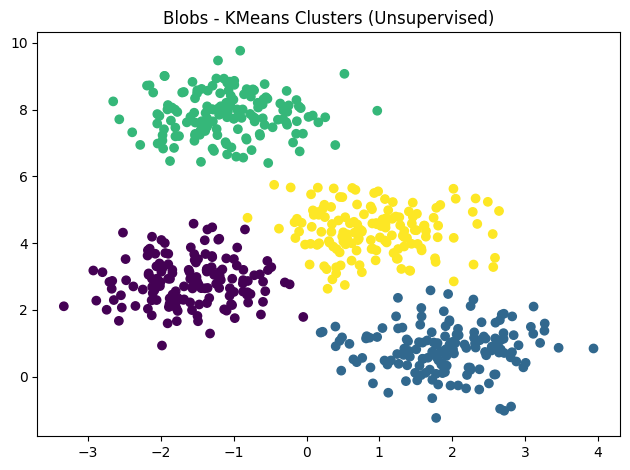

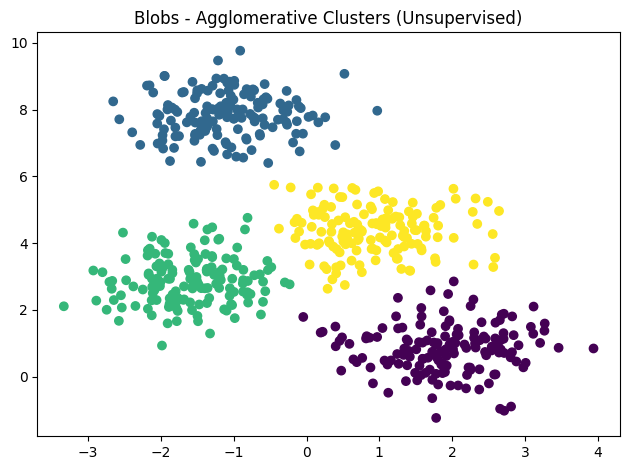

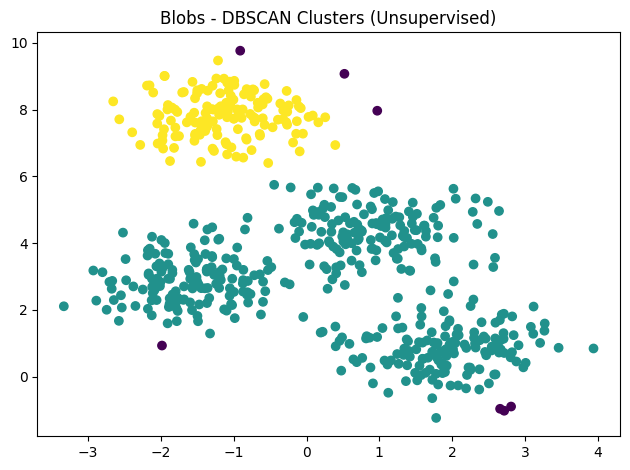

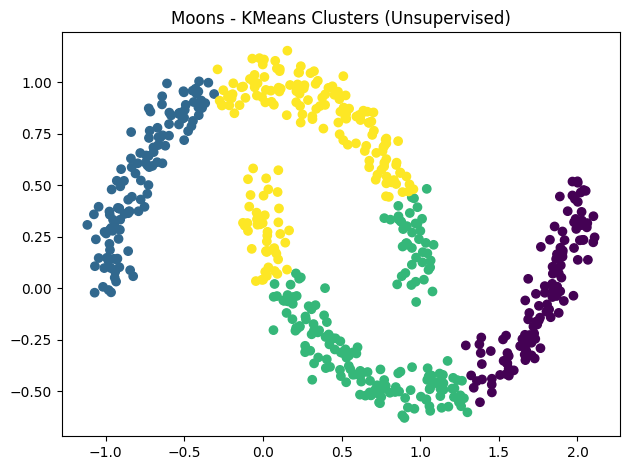

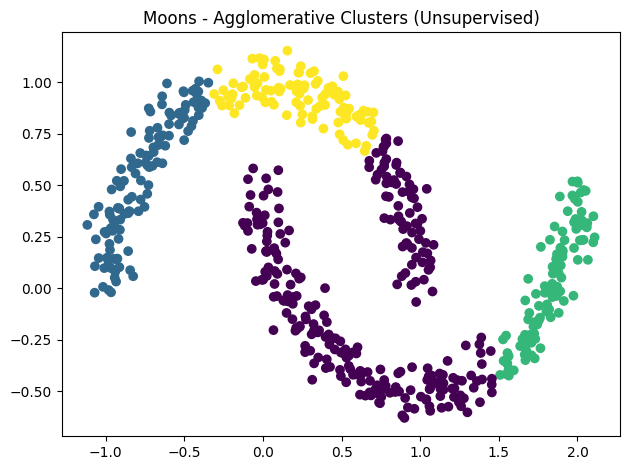

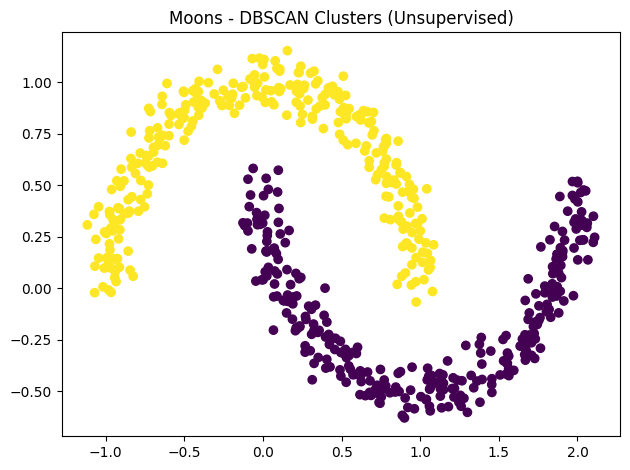

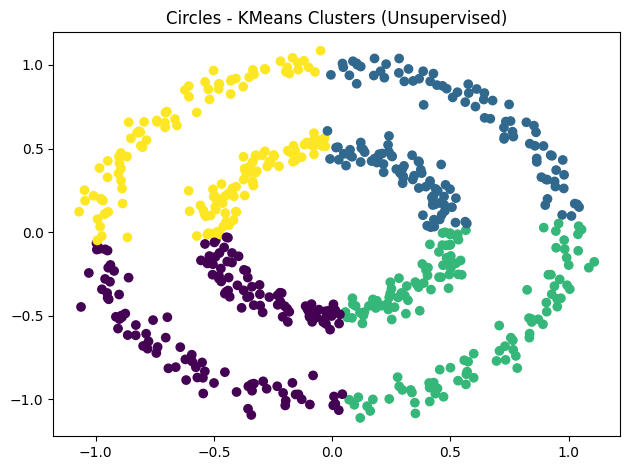

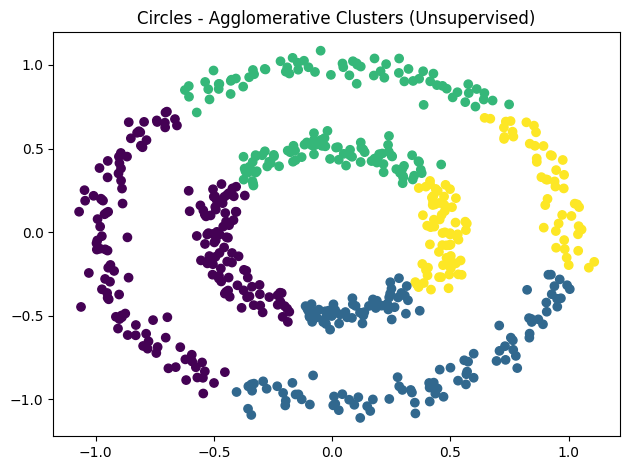

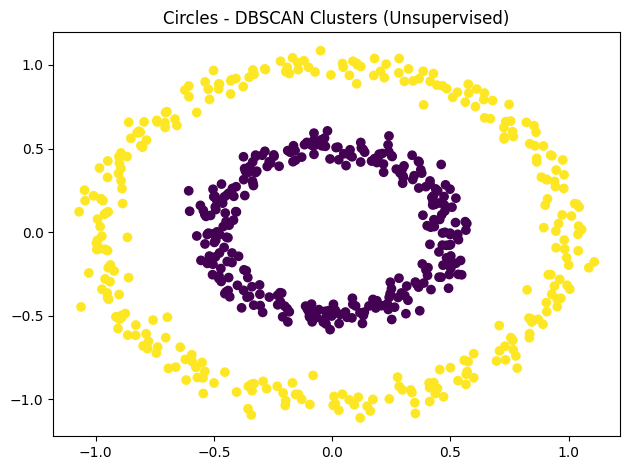

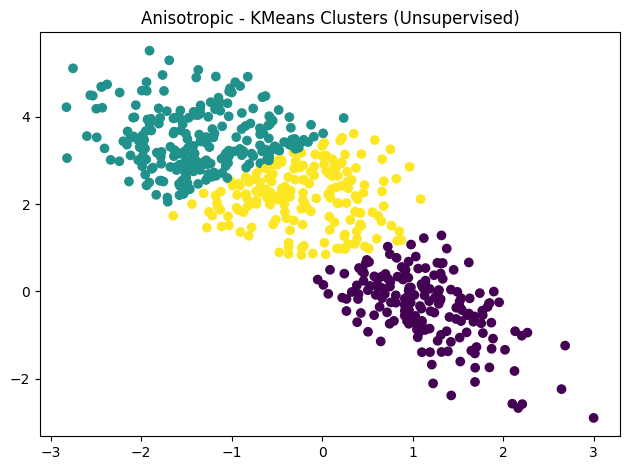

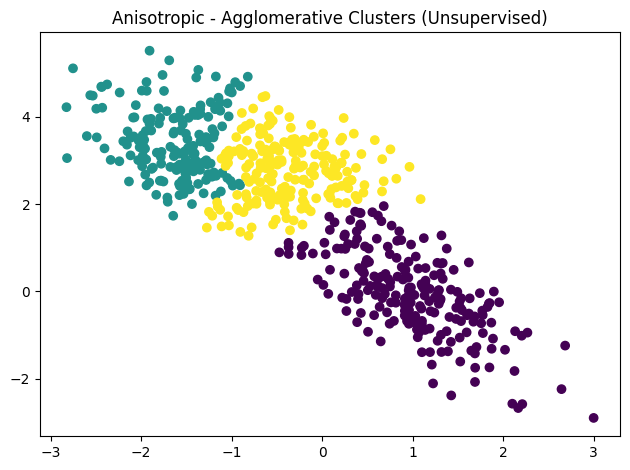

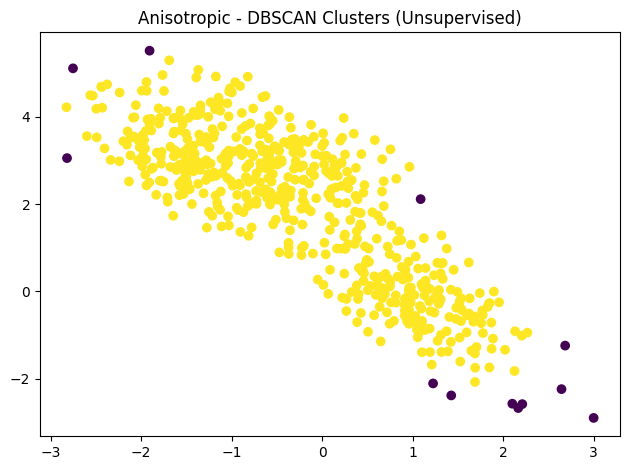

In [10]:
# VISUALIZE CLUSTER RESULTS
for name, (X, _) in datasets.items():
    for algo in algorithms:
        labels = results[name][algo]["labels"]
        plt.figure()
        plt.scatter(X[:, 0], X[:, 1], c=labels)
        plt.title(f"{name} - {algo} Clusters (Unsupervised)")
        plt.tight_layout()

plt.show()

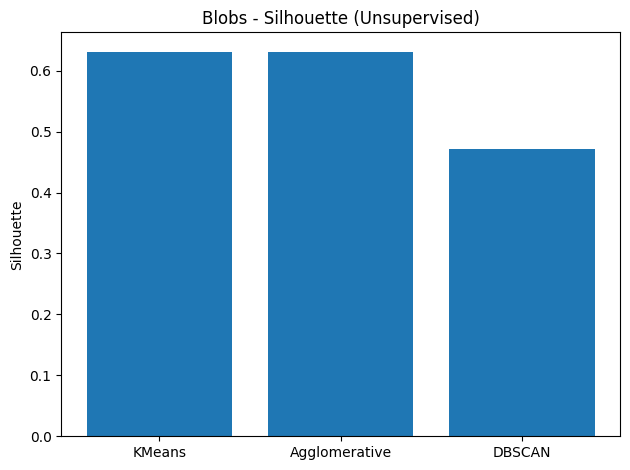

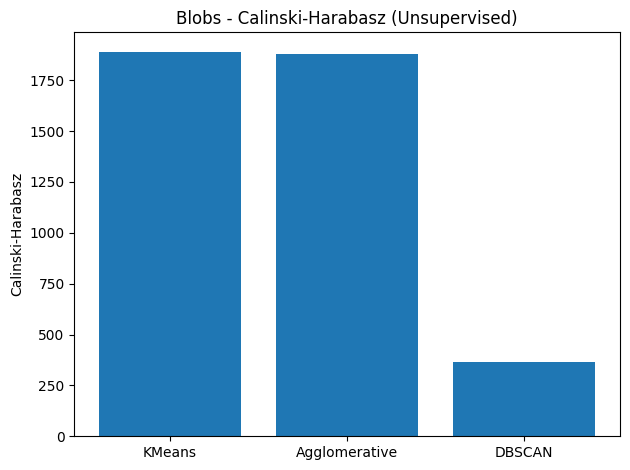

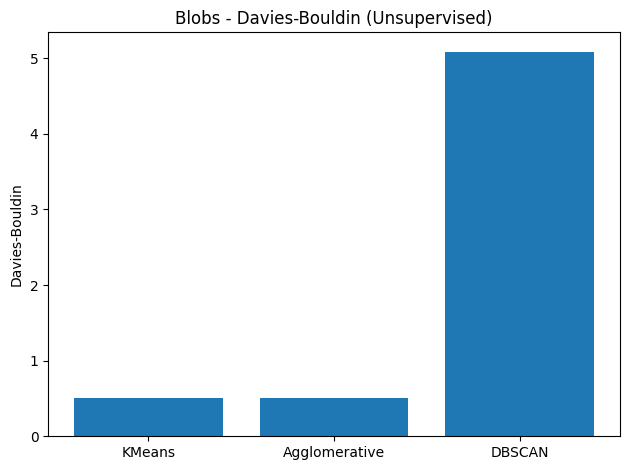

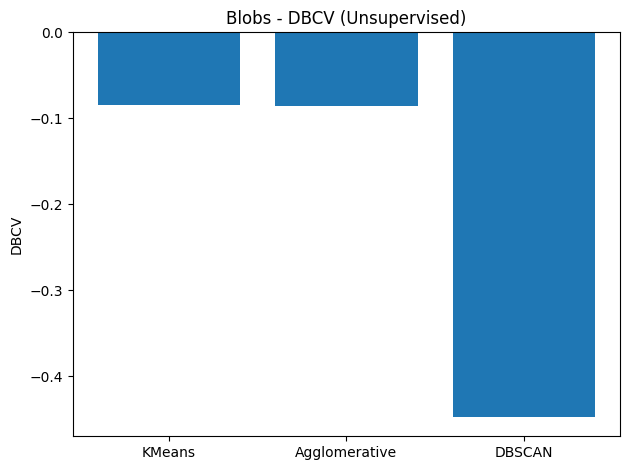

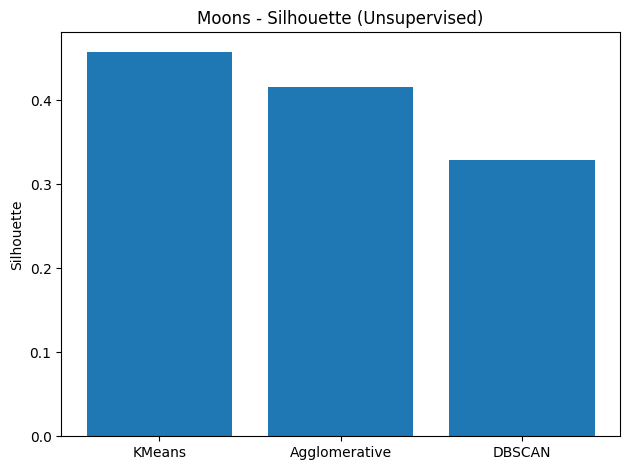

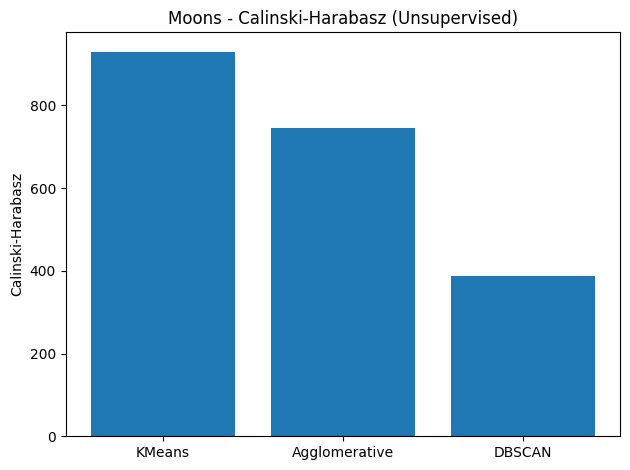

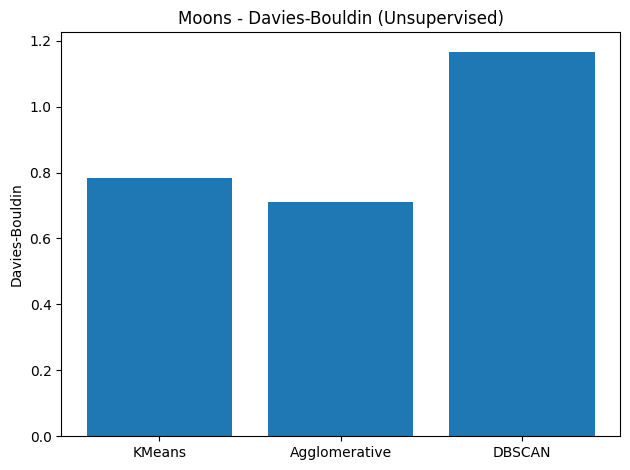

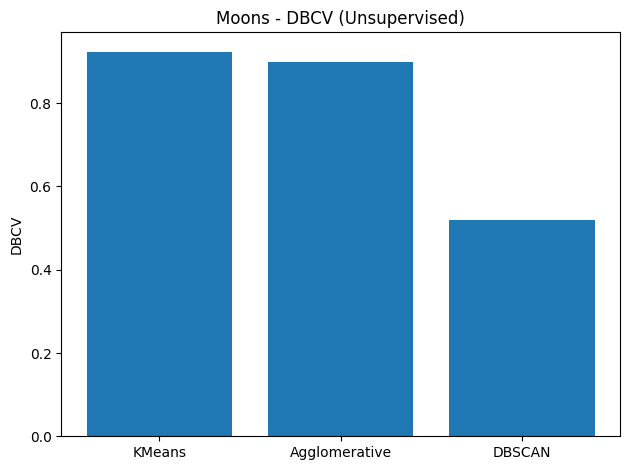

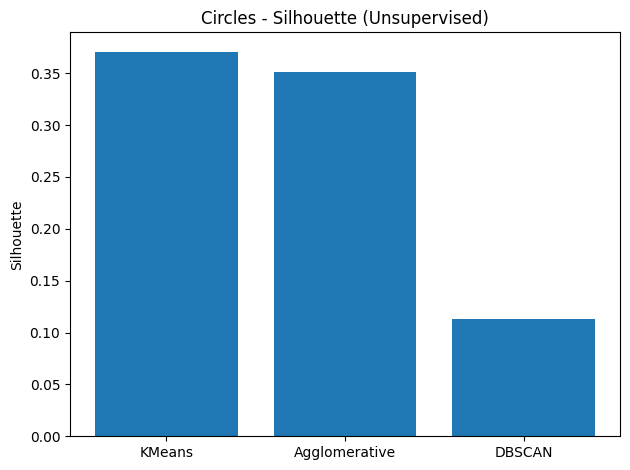

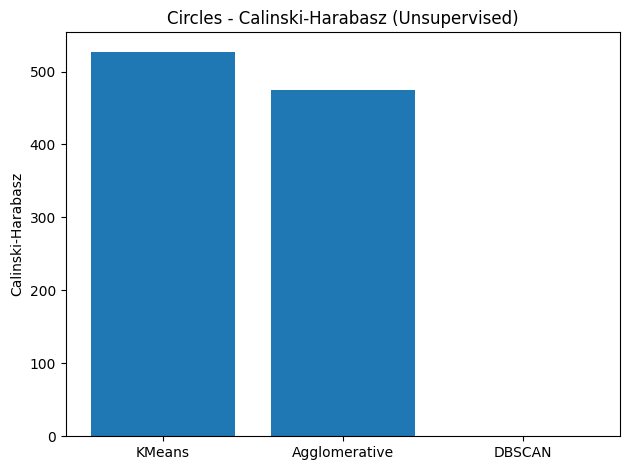

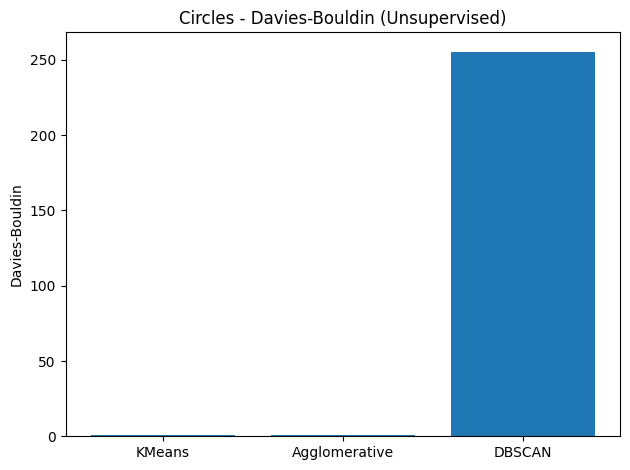

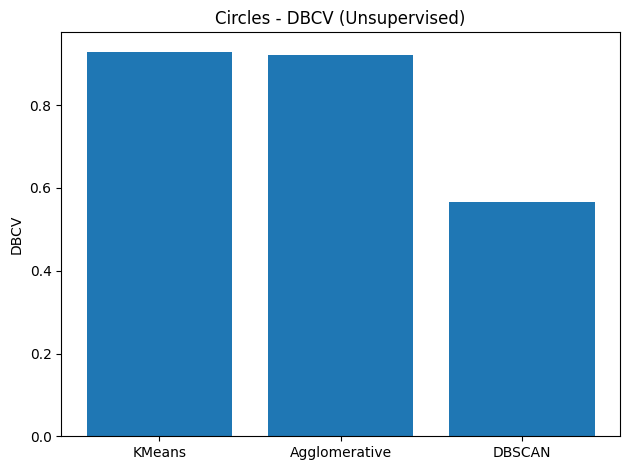

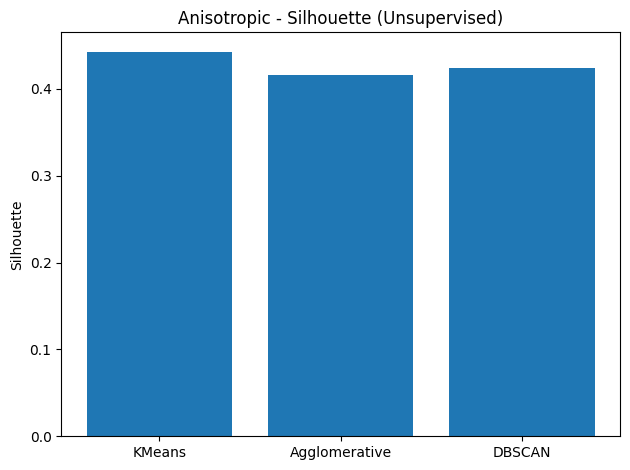

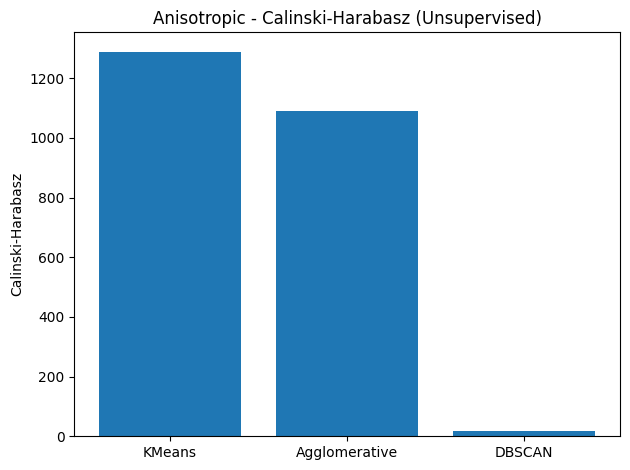

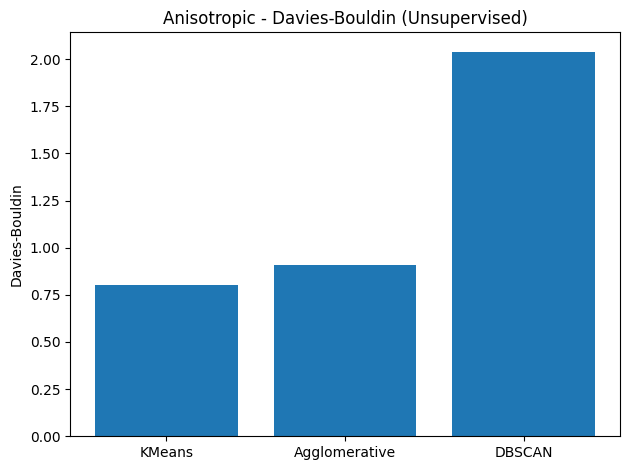

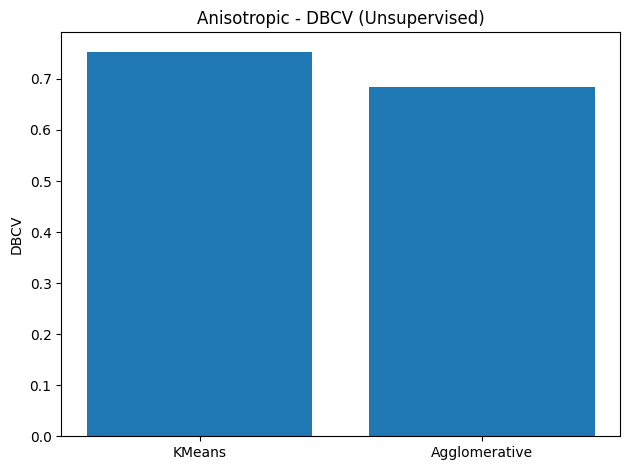

In [11]:
# PLOT METRIC COMPARISONS

metric_names = ["Silhouette", "Calinski-Harabasz", "Davies-Bouldin", "DBCV"]

for name in datasets.keys():
    for metric in metric_names:
        values = []
        algos_with_values = []

        for algo in algorithms:
            val = results[name][algo]["metrics"][metric]
            if val is not None:
                values.append(val)
                algos_with_values.append(algo)

        if not values:
            continue

        plt.figure()
        x = np.arange(len(algos_with_values))
        plt.bar(x, values)
        plt.xticks(x, algos_with_values)
        plt.title(f"{name} - {metric} (Unsupervised)")
        plt.ylabel(metric)
        plt.tight_layout()

plt.show()